In [1]:
import os
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

In [2]:
feature_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(224,224,3)
)

print("Feature extractor loaded.")

Feature extractor loaded.


In [4]:
features = np.load("features/feature_vectors.npy")

with open("features/image_paths.pkl","rb") as f:
    image_paths = pickle.load(f)

with open("features/labels.pkl","rb") as f:
    labels = pickle.load(f)

print("Dataset Images :", len(image_paths))
print("Feature Shape :", features.shape)

Dataset Images : 2872
Feature Shape : (2872, 1280)


In [6]:
captured_image = "captured/current_face.jpg"

if not os.path.exists(captured_image):
    raise FileNotFoundError("Run Notebook 3 first to capture a face.")

In [7]:
img = image.load_img(captured_image, target_size=(224,224))
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = preprocess_input(img)

query_feature = feature_model.predict(img, verbose=0)

In [8]:
similarities = cosine_similarity(query_feature, features)[0]

In [9]:
top5 = np.argsort(similarities)[::-1][:5]

for rank, idx in enumerate(top5, start=1):
    print(
        f"{rank}. "
        f"{os.path.basename(image_paths[idx])} | "
        f"Skin: {labels[idx]} | "
        f"Similarity: {similarities[idx]*100:.2f}%"
    )

1. dry_e6da0d5885a2761f7138_jpg.rf.402e491a9a34a4ae7481583a84af875f.jpg | Skin: dry | Similarity: 60.72%
2. oily_new_2d9161f912872bd38c82_jpg.rf.96919c7960b1cbba7605a4c2dc0ffb8d.jpg | Skin: oily | Similarity: 59.80%
3. dry_652a087f0622a899f4d1_jpg.rf.c0613b8ef4a6e228992292c6837c5a95.jpg | Skin: dry | Similarity: 57.23%
4. dry_new_a21418631e9ea9903e3b_jpg.rf.bffde7c58937dfc1ca3aa3e417dc7dd4.jpg | Skin: dry | Similarity: 55.81%
5. normal_37a7fa4900efa017a891_jpg.rf.b468f27c65350825219e4c3759c3d0c3.jpg | Skin: normal | Similarity: 55.64%


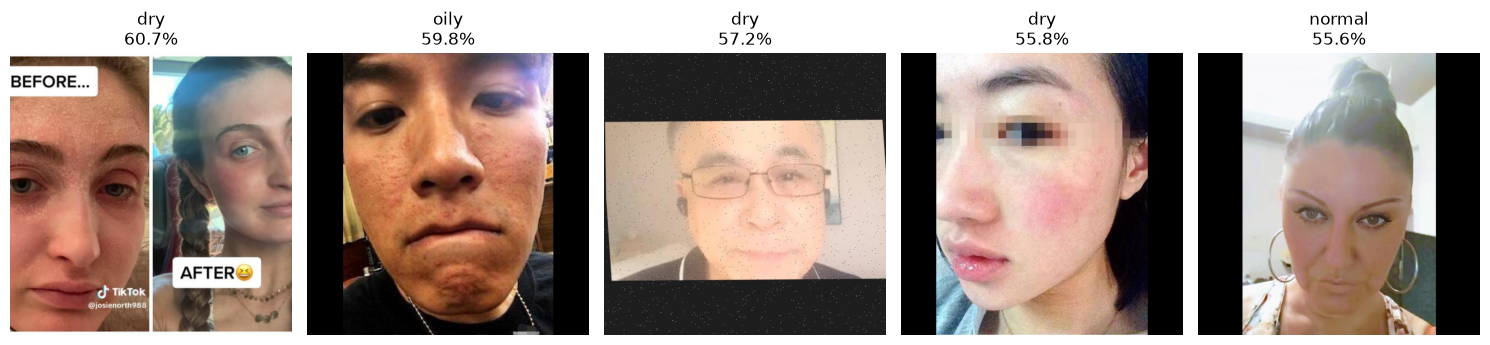

In [10]:
plt.figure(figsize=(15,4))

for i, idx in enumerate(top5):

    img = cv2.imread(image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(
        f"{labels[idx]}\n{similarities[idx]*100:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

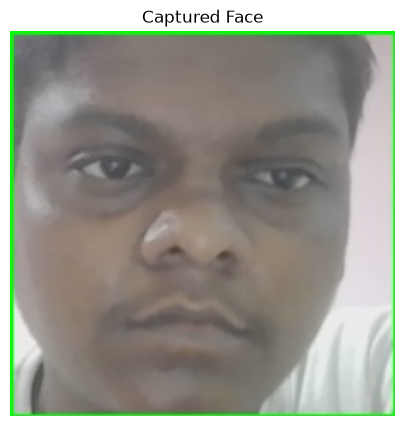

In [12]:
img = cv2.imread(captured_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Captured Face")
plt.axis("off")
plt.show()